### Imports

In [10]:
import numpy as np
from maraboupy import Marabou
import time
import itertools
import matplotlib.pyplot as plt
from contextlib import redirect_stdout
import os

### Setup

In [11]:
options = Marabou.createOptions(verbosity = 0)

- Get neural net feature indices and identify corresponding variables

In [12]:
features = np.load("../../data/features.npy", allow_pickle=True)

print(features[:10], "...")
print()
print("size:", len(features))

['age' 'fnlwgt' 'education.num' 'capital.gain' 'capital.loss'
 'hours.per.week' 'workclass_ ?' 'workclass_ Federal-gov'
 'workclass_ Local-gov' 'workclass_ Never-worked'] ...

size: 108


In [13]:
non_categorical = set(range(6))

workclass = set(range(6,15))

education = set(range(15,31))

marital_status = set(range(31,38))

occupation = set(range(38,53))

relationship = set(range(53,59))

race = set(range(59,64))

sex = set(range(64,66))

native_country = set(range(66,108))

all_groups = [workclass, education, marital_status, occupation, relationship, race, sex, native_country]

# Disclaimer

A good chunk of the code below has various issues.

### Fairness

- Before proceeding, it's important to understand why we need a fairness check for a model like this.
- Suppose a bank uses this model to decide who to grant loans to. If they make more than or equal to $50K, they are more likely to qualify for the loan, and vice versa.
- Now, what if the model learns that people belonging to a certain minority group are more likely to earn less than $50K? It'll give this information to the bank, which then is less likely to sponsor loans to these minority groups, perputuating the cycle. This is unfair.
- We thus want our model to be fair - regardless of changing certain identitarian criteria.

----
- Define functions

In [14]:
### [AI DISCLOSURE: Understanding original code and contraint-writing.]

def setup_networks(model_path:str, target_group:set[int], class_A:int, class_B:int):
    """
    Load two copies of the network and set up input equality constraints,
    except for the inputs for the one-hot-encoded class, where we enforce a reassignment.
    Returns the two network objects.
    """
    net1 = Marabou.read_onnx(model_path)
    net2 = Marabou.read_onnx(model_path)

    # Retrieve the input variable lists (assuming one input layer)
    inputs1 = net1.inputVars[0][0].tolist()
    inputs2 = net2.inputVars[0][0].tolist()

    # for both networks, add contraints so that multiclass one hot encoding is maintained for examples. 
    for group in all_groups:
        if group == target_group:
            continue

        group_vars1 = [inputs1[i] for i in group]
        group_vars2 = [inputs2[i] for i in group]
        coeffs = [1] * len(group)
        
        # Add constraint: sum(group_vars) = 1
        net1.addEquality(group_vars1, coeffs, 1) # For net1
        net2.addEquality(group_vars2, coeffs, 1) # For net2

    # For all inputs except those in the range of the one-hot-encoded classes, enforce equality: input1[i] == input2[i]
    for i in range(len(inputs1)):

        if i not in target_group:
            net1.addEquality([inputs1[i], inputs2[i]], [1, -1], 0)

    # CRITICAL FIX: Ensure exactly one race is selected in each network
    # For net1: class_A OR class_B is active (but not both)
    net1.addEquality([inputs1[class_A], inputs1[class_B]], [1, 1], 1)
    # A1 != B1
    
    # For net2: class_A OR class_B is active (but not both)  
    net2.addEquality([inputs2[class_A], inputs2[class_B]], [1, 1], 1)
    # A2 != B2

    # CRITICAL FIX: Swap the races between the two networks
    net1.addEquality([inputs1[class_A], inputs2[class_B]], [1, -1], 0)
    # A1 = B2 => 
    # A1 != A2, B1 != B2
    
    # make sure this applies to only (eg.) white and black persons in both networks.
    for i in (target_group - {class_A, class_B}):

        net1.setUpperBound(inputs1[i], 0) 
        net2.setUpperBound(inputs2[i], 0)
    
    return net1, net2

In [15]:
### [AI DISCLOSURE: Understanding original code and some modifications necessary]

def check_case(case:int, model_path:str, target_group:set[int], class_A:int, class_B:int, threshold:float, epsilon:float):
    """
    Check one of the fairness violation cases.
    case == 1: net1 output >= threshold and net2 output < threshold
    case == 2: net1 output < threshold and net2 output >= threshold
    """
    start_time = time.time()
    

    #for class_A, class_B in list(itertools.combinations(target_group, 2)):
    # Setup networks and constraints common to both
    net1, net2 = setup_networks(model_path, target_group, class_A, class_B)
    
    # Retrieve the output variables
    output1 = net1.outputVars[0][0][0]
    output2 = net2.outputVars[0][0][0]

    
    if case == 1:
        net1.setLowerBound(output1, threshold)
        net1.setUpperBound(output2, threshold - epsilon)
    elif case == 2:
        net1.setUpperBound(output1, threshold - epsilon)
        net1.setLowerBound(output2, threshold)
    else:
        raise ValueError("Case must be 1 or 2.")
    
    with open(os.devnull, "w") as fnull: # remove verbose output
        with redirect_stdout(fnull):
            exitCode, vals, stats = net1.solve(options = options)
    elapsed_time = time.time() - start_time
    
    return exitCode, vals, elapsed_time

In [16]:
def fairness_check(model_path:str, target_group:set[int], threshold:float, epsilon:float):
    '''
    Check all pairs in a given categorical class to see if any of them provide a SATisfying counterexample
    '''

    start_time = time.time()
    
    for class_A, class_B in list(itertools.combinations(target_group, 2)):

        exitCode1, vals1, time1 = check_case(1, model_path, target_group, class_A, class_B, threshold, epsilon)
        #print("Time Taken (Case 1) =", round(time1, 4), "seconds")
        if exitCode1 == "sat":
            print(f"Fairness violation found (Case 1): Found a pair of classes ({class_A}, {class_B}) which change the outcome if swapped.")

            elapsed_time = time.time() - start_time

            return vals1, elapsed_time

        else:
            exitCode2, vals2, time2 = check_case(2, model_path, target_group, class_A, class_B, threshold, epsilon)
            #print("Time Taken (Case 2) =", round(time2, 4), "seconds")

            if exitCode2 == "sat":
                print(f"Fairness violation found (Case 2): Found a pair of classes ({class_A}, {class_B}) which change the outcome if swapped.")
                
                elapsed_time = time.time() - start_time

                return vals2, elapsed_time

            else:
                pass
    
    print(f"No fairness violations were found for any of the classes in {target_group}")

    elapsed_time = time.time() - start_time

    return None, elapsed_time

In [17]:
### [AI Generated - DeepSeek]

def plot_timing_results(category:str, models, times, outcomes):
    """
    Plot timing results with outcome labels on top of each bar
    """
    plt.figure(figsize=(16, 9))
    
    bars = plt.bar(models, times, alpha=0.7)
        
    # Customize the plot
    plt.title(f'{category} Check', fontsize=14)
    plt.xlabel('Models', fontsize=12)
    plt.ylabel('Time (seconds)', fontsize=12)
    plt.grid(axis='y', alpha=0.3)
    
    # Add outcome labels on top of each bar
    for bar, outcome, time in zip(bars, outcomes[:20], times[:20]):
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2., height + 0.01,
                f'{outcome}',
                ha='center', va='bottom', fontsize=9)
    
    plt.tight_layout()
    plt.show()

# Overview

- The code here has largely been adapted from what was present in the notebooks originally in the repo ('Verify.ipynb').

- However, it seems that this always gives UNSAT results. Why?
    - Because the primary network (net1) and the counterfactual network (net2) remain wholly unrelated with each other. Note that the code never tries to solve net2, even though we require it as a counterfactual check!
    - net2 essentially ends up acting like a free variable! The code correctly adds the variables from net2 (like inputs2 and output2) into the net1 problem scope when it calls net1.addEquality([inputs1[i], inputs2[i]], ...) or net1.setUpperBound(output2, ...)
    - However, net1.solve() has no information about the net2 network structure. So inputs2 and outputs2 become some arbitrary free variables which it can always assign.
    - As a result, it becomes impossible to find a SATisfying counterexample.

- This is my theory, I might just be doing everything incorrectly. I have **attempted a fix in 'CorrectAttempt.ipynb'**, which the reader may consult.

- I might just be doing everything wrong - Marabou's own documentation is for version 1.0.0 and is quite outdated. I've adapted to the best of my ability.

#### Race

Let $race(x)$ denote the race one-hot subvector of $x$, and
let $RaceVals$ be the set of valid race encodings. For any $x \in \mathcal{X}$ define $x'$ to be $x$ with $race(x)$
replaced (all other coordinates unchanged). The model is fair at $x$ *iff*

$$\forall \ race(x) \in RaceVals \ \left( \^{y}(x) = \^{y}(x') \right)$$

**Verification target**: search for a violation—i.e., SAT of

$$\exists \ x \in \mathcal{X}, \ \exists \ race(x) \in RaceVals \ \left( \^{y}(x) \neq \^{y}(x') \right)$$

A SATisfying assignment will show that our model has some racial bias.



No fairness violations were found for any of the classes in {59, 60, 61, 62, 63}
Assignment Found: None
Time Taken: 5.355001211166382
No fairness violations were found for any of the classes in {59, 60, 61, 62, 63}
Assignment Found: None
Time Taken: 11.463719129562378
No fairness violations were found for any of the classes in {59, 60, 61, 62, 63}
Assignment Found: None
Time Taken: 27.03018569946289

No fairness violations were found for any of the classes in {59, 60, 61, 62, 63}
Assignment Found: None
Time Taken: 5.439451456069946
No fairness violations were found for any of the classes in {59, 60, 61, 62, 63}
Assignment Found: None
Time Taken: 19.35339665412903
No fairness violations were found for any of the classes in {59, 60, 61, 62, 63}
Assignment Found: None
Time Taken: 35.780072927474976

No fairness violations were found for any of the classes in {59, 60, 61, 62, 63}
Assignment Found: None
Time Taken: 5.152923583984375
No fairness violations were found for any of the classes i

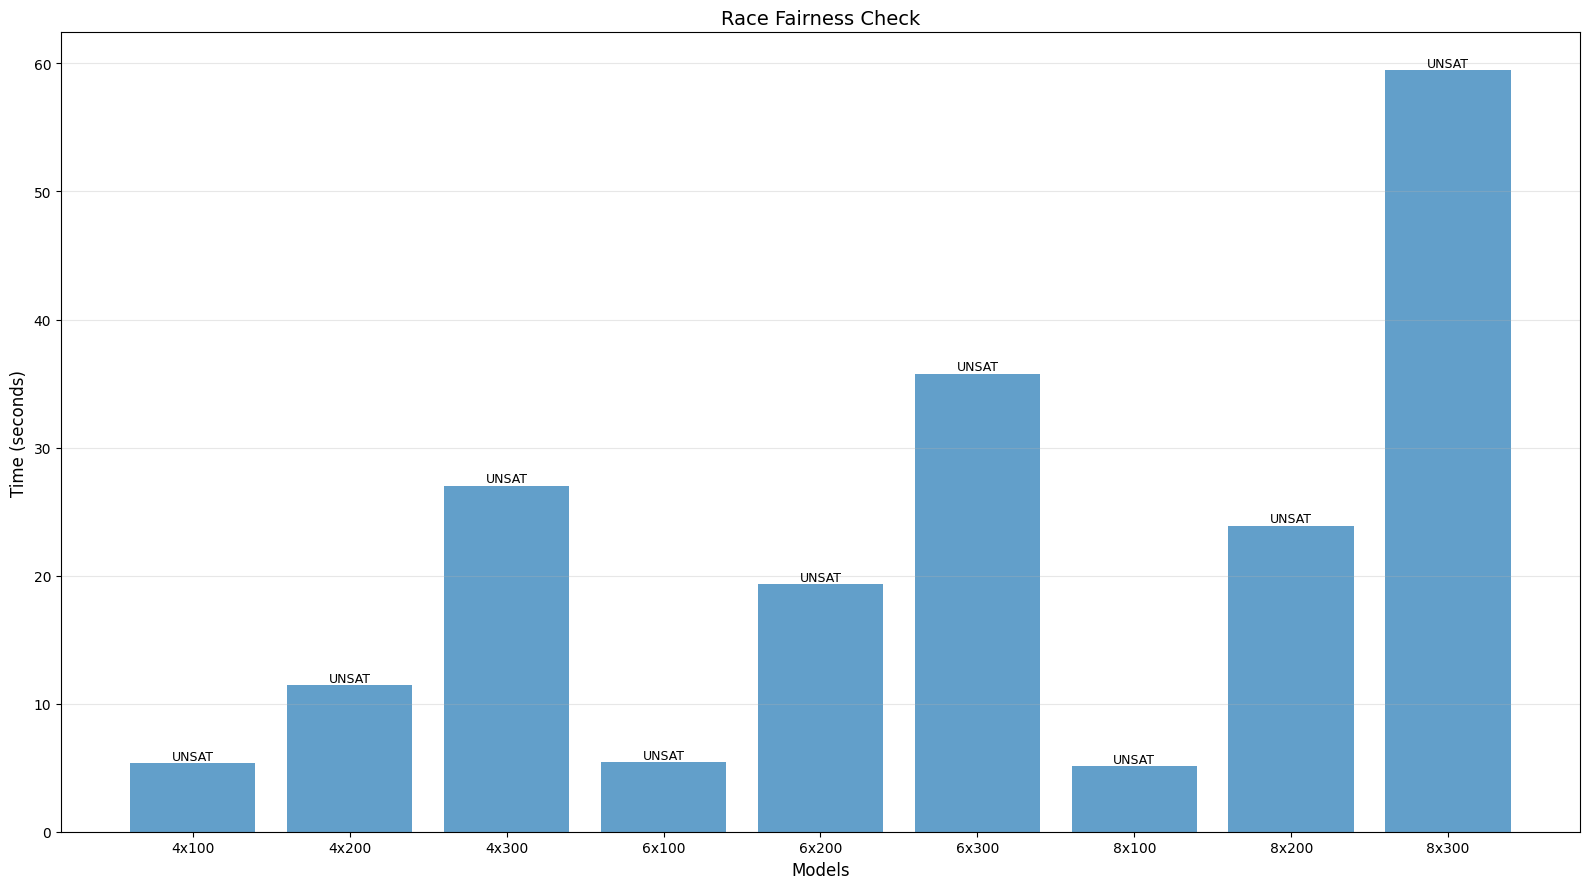

In [18]:
models = []
times = []
outcomes = []

for layers in range(4,9,2):

    for width in range(100, 301, 100):

        models.append(f"{layers}x{width}")

        model_path = f'../../models/{layers}_layers/model_{layers}x{width}.onnx'
        assignment, time_taken = fairness_check(model_path, race, threshold = 0.5, epsilon= 1e-3)

        times.append(time_taken)

        print("Assignment Found:", assignment)
        print("Time Taken:", time_taken)

        if assignment is not None:
            outcomes.append("SAT")
        else:
            outcomes.append("UNSAT")

    print()

plot_timing_results("Race Fairness", models, times, outcomes)

#### Gender (binary)

Let $gender(x)$ denote the gender one-hot subvector of $x$, and
let $GenderVals$ be the set of valid gender encodings. For any $x \in \mathcal{X}$ define $x'$ to be $x$ with $gender(x)$
replaced (all other coordinates unchanged). The model is fair at $x$ *iff*

$$\forall \ race(x) \in GenderVals \ \left( \^{y}(x) = \^{y}(x') \right)$$

**Verification target**: search for a violation—i.e., SAT of

$$\exists \ x \in \mathcal{X}, \ \exists \ gender(x) \in GenderVals \ \left( \^{y}(x) \neq \^{y}(x') \right)$$

A SATisfying assignment will show that our model discriminates based on gender

No fairness violations were found for any of the classes in {64, 65}
Assignment Found: None
Time Taken: 0.41056323051452637
No fairness violations were found for any of the classes in {64, 65}
Assignment Found: None
Time Taken: 0.704949140548706
No fairness violations were found for any of the classes in {64, 65}
Assignment Found: None
Time Taken: 1.5758025646209717

No fairness violations were found for any of the classes in {64, 65}
Assignment Found: None
Time Taken: 0.36818361282348633
No fairness violations were found for any of the classes in {64, 65}
Assignment Found: None
Time Taken: 1.1696560382843018
No fairness violations were found for any of the classes in {64, 65}
Assignment Found: None
Time Taken: 2.562615156173706

No fairness violations were found for any of the classes in {64, 65}
Assignment Found: None
Time Taken: 0.522881031036377
No fairness violations were found for any of the classes in {64, 65}
Assignment Found: None
Time Taken: 1.846992015838623
No fairness viol

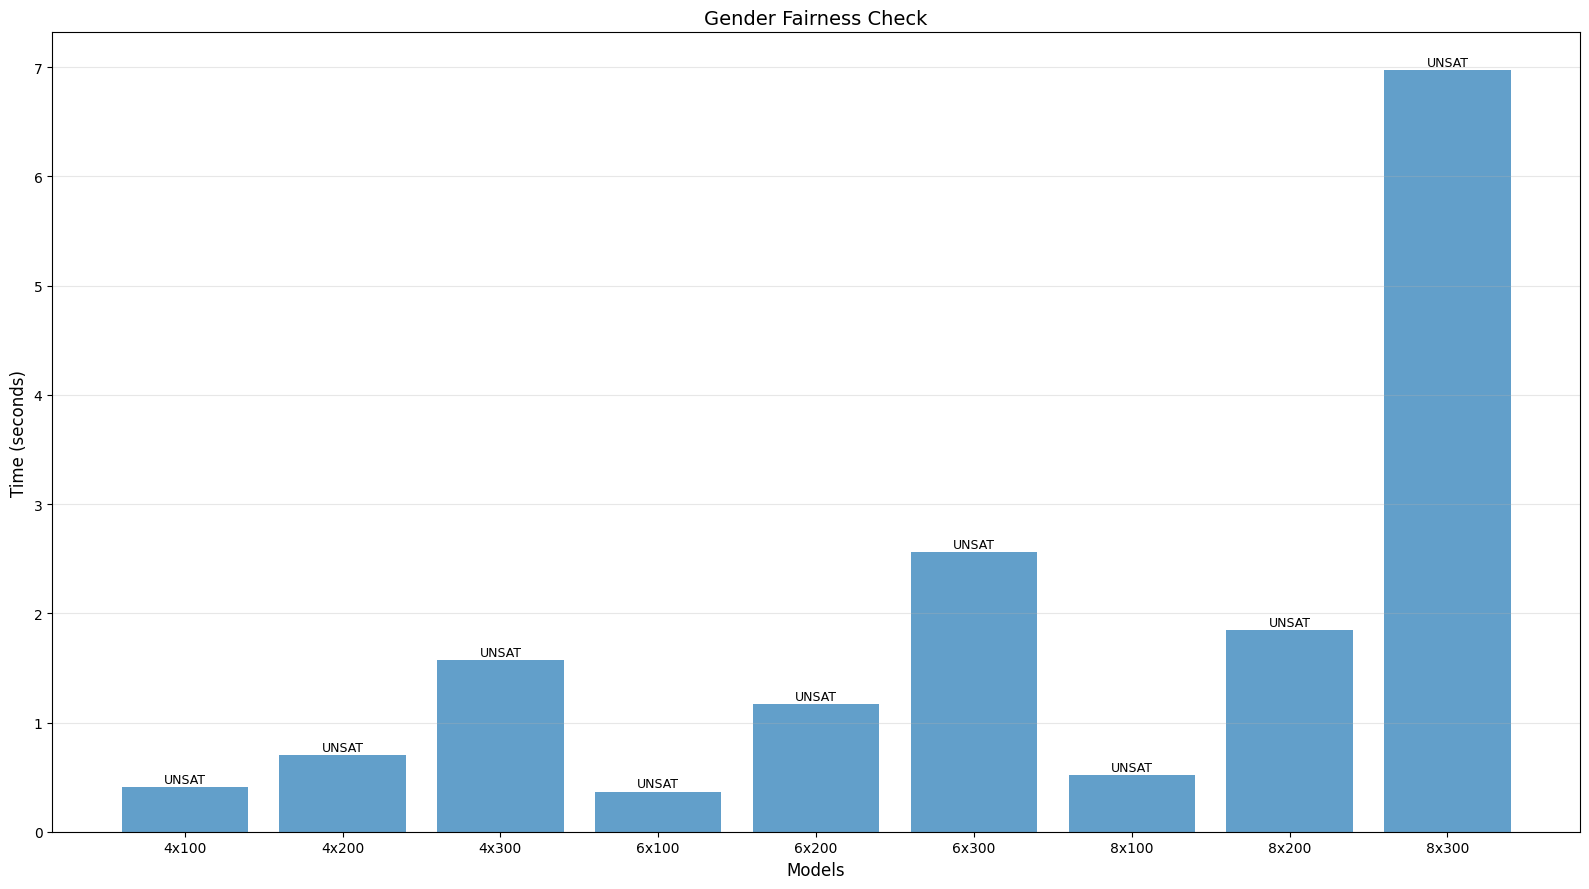

In [19]:
models = []
times = []
outcomes = []

for layers in range(4,9,2):

    for width in range(100, 301, 100):

        models.append(f"{layers}x{width}")

        model_path = f'../../models/{layers}_layers/model_{layers}x{width}.onnx'
        assignment, time_taken = fairness_check(model_path, sex, threshold = 0.5, epsilon= 1e-3)

        times.append(time_taken)

        print("Assignment Found:", assignment)
        print("Time Taken:", time_taken)

        if assignment is not None:
            outcomes.append("SAT")
        else:
            outcomes.append("UNSAT")

    print()

plot_timing_results("Gender Fairness", models, times, outcomes)
# gender != sex but that's the assumption the data forces us to make :(

#### Marital Status

Let $marital(x)$ denote the marital status one-hot subvector of $x$, and
let $MaritalVals$ be the set of valid Marital Satus encodings. For any $x \in \mathcal{X}$ define $x'$ to be $x$ with $marital(x)$
replaced (all other coordinates unchanged). The model is fair at $x$ *iff*

$$\forall \ marital(x) \in MaritalVals \ \left( \^{y}(x) = \^{y}(x') \right)$$

**Verification target**: search for a violation—i.e., SAT of

$$\exists \ x \in \mathcal{X}, \ \exists \ marital(x) \in MaritalVals \ \left( \^{y}(x) \neq \^{y}(x') \right)$$

A SATisfying assignment will show that our model discriminates based on the marital status of a person.

No fairness violations were found for any of the classes in {32, 33, 34, 35, 36, 37, 31}
Assignment Found: None
Time Taken: 5.571439266204834
No fairness violations were found for any of the classes in {32, 33, 34, 35, 36, 37, 31}
Assignment Found: None
Time Taken: 16.195829391479492
No fairness violations were found for any of the classes in {32, 33, 34, 35, 36, 37, 31}
Assignment Found: None
Time Taken: 34.54939150810242

No fairness violations were found for any of the classes in {32, 33, 34, 35, 36, 37, 31}
Assignment Found: None
Time Taken: 7.856027603149414
No fairness violations were found for any of the classes in {32, 33, 34, 35, 36, 37, 31}
Assignment Found: None
Time Taken: 28.48945116996765
No fairness violations were found for any of the classes in {32, 33, 34, 35, 36, 37, 31}
Assignment Found: None
Time Taken: 59.81359624862671

No fairness violations were found for any of the classes in {32, 33, 34, 35, 36, 37, 31}
Assignment Found: None
Time Taken: 10.984132289886475
No

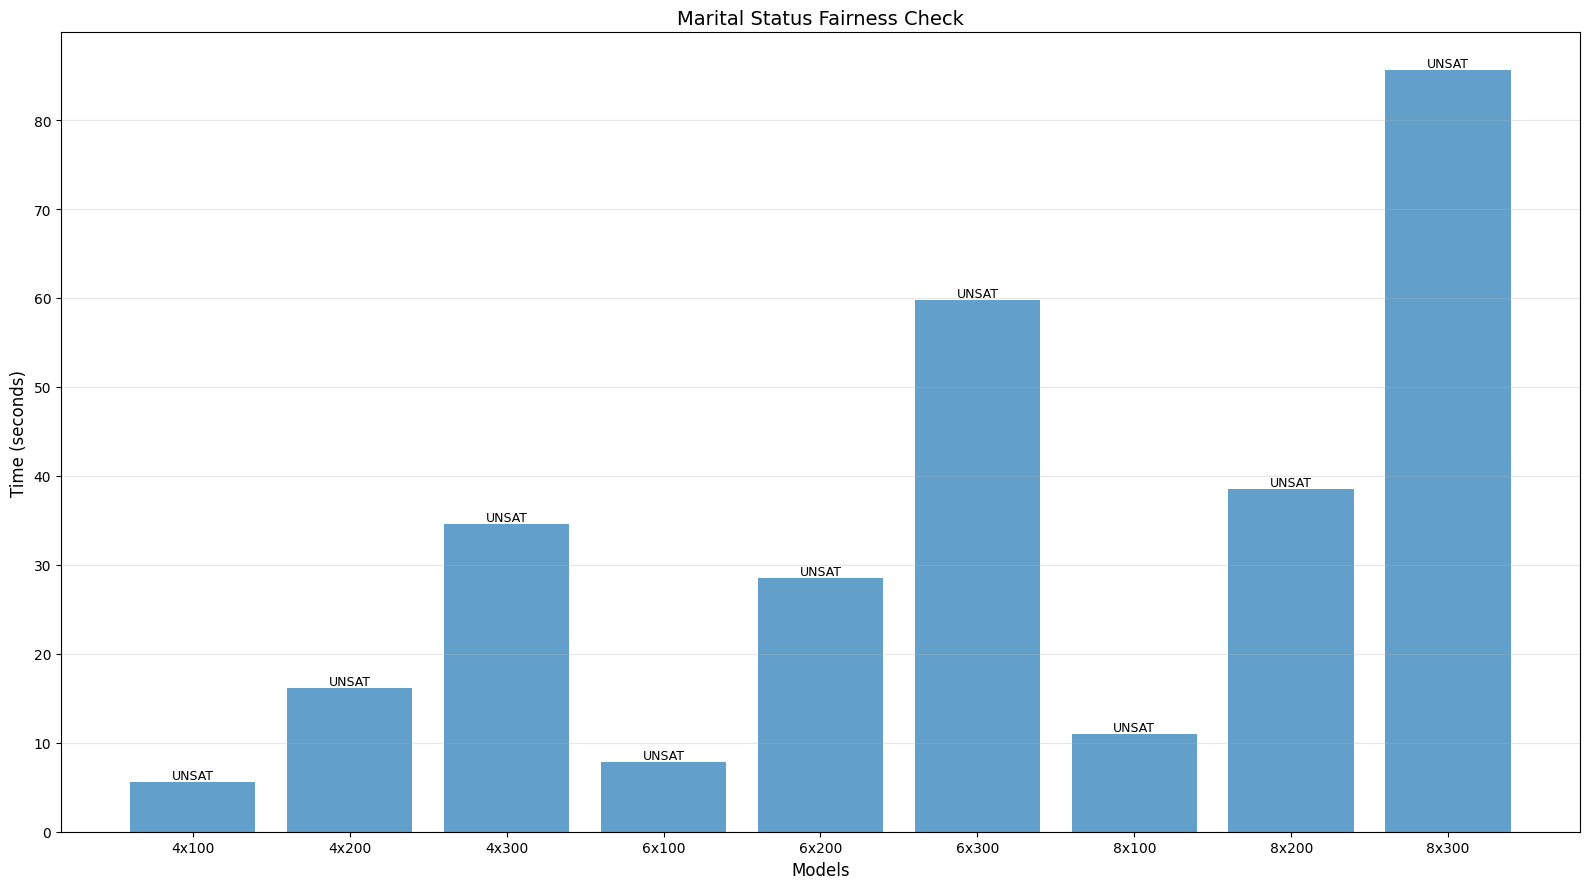

In [20]:
models = []
times = []
outcomes = []

for layers in range(4,9,2):

    for width in range(100, 301, 100):

        models.append(f"{layers}x{width}")

        model_path = f'../../models/{layers}_layers/model_{layers}x{width}.onnx'
        assignment, time_taken = fairness_check(model_path, marital_status, threshold = 0.5, epsilon= 1e-3)

        times.append(time_taken)

        print("Assignment Found:", assignment)
        print("Time Taken:", time_taken)

        if assignment is not None:
            outcomes.append("SAT")
        else:
            outcomes.append("UNSAT")

    print()

plot_timing_results("Marital Status Fairness", models, times, outcomes)

#### Country of Origin

Let $country(x)$ denote the country one-hot subvector of $x$, and
let $CountryVals$ be the set of valid Country of Origin encodings. For any $x \in \mathcal{X}$ define $x'$ to be $x$ with $country(x)$
replaced (all other coordinates unchanged). The model is fair at $x$ *iff*

$$\forall \ country(x) \in CountryVals \ \left( \^{y}(x) = \^{y}(x') \right)$$

**Verification target**: search for a violation—i.e., SAT of

$$\exists \ x \in \mathcal{X}, \ \exists \ country(x) \in CountryVals \ \left( \^{y}(x) \neq \^{y}(x') \right)$$

A SATisfying assignment will show that our model discriminates based on the country of origin of a person.

In [ ]:
models = []
times = []
outcomes = []

for layers in range(4,9,2):

    for width in range(100, 301, 100):

        models.append(f"{layers}x{width}")

        model_path = f'../../models/{layers}_layers/model_{layers}x{width}.onnx'
        assignment, time_taken = fairness_check(model_path, native_country, threshold = 0.5, epsilon= 1e-3)

        times.append(time_taken)

        print("Assignment Found:", assignment)
        print("Time Taken:", time_taken)

        if assignment is not None:
            outcomes.append("SAT")
        else:
            outcomes.append("UNSAT")

    print()

plot_timing_results("Country of Origin Fairness", models, times, outcomes)

### Robustness

For $ y \in \{0, 1\} $, let $ \mu_y $ be the mean input (in normalized feature space) over the subset with label $ y $. Fix $ \epsilon > 0 $ and norm $ \|\cdot\|_\infty $. Define the admissible $ \epsilon $-ball:

$$
B_\infty(\mu_y, \epsilon) = \{x : \|x - \mu_y\|_\infty \leq \epsilon, \text{ continuous features within bounds, categoricals remain valid one-hot}\},
$$

The model is **robust at** $ \mu_y $ **iff**:

$$
\forall x \in B_\infty(\mu_y, \epsilon) : \hat{y}(x) = \hat{y}(\mu_y),
$$

In [22]:
### Adapted from Original Notebook code.

def epsilon_ball(model_path:str, epsilon = 0.01):

    start_time = time.time()

    options = Marabou.createOptions(verbosity = 0)

    net = Marabou.read_onnx(model_path)

    # Load x_avg from file
    x_avg = np.load("../../data/x_avg.npy")

    # Access the input variable list; adjust indexing based on your network structure.
    # Here we assume net.inputVars[0][0] is an array of input variable IDs.
    inputs = net.inputVars[0][0].tolist()

    # Set epsilon as some percentage of the average for each input dimension.
    for i, var in enumerate(inputs):

        epsilon_i = epsilon * abs(x_avg[i])

        net.setLowerBound(var, x_avg[i] - epsilon_i)
        net.setUpperBound(var, x_avg[i] + epsilon_i)
    
    '''# we do not want our model to create counterexample inputs that can never occur in reality.
    for i in range(len(inputs)):
        if i in non_categorical:
            lower, upper = -3, 3
            # non categorical features were normalized using StandarScalar, and thus follow
            # the normal distrubution. 99.7% of the data lies within the std dev 3, so we set these bounds
        else:
            lower, upper = 0, 1
            # one hot encoded - variables are either true or false.
        
        net.setLowerBound(inputs[i], lower)
        net.setUpperBound(inputs[i], upper)
'''

    # the block comment above is crucial for consistency! but slows down marabou! without it, SAT outputs are produced 
    # make one hot encoded features (0/1) take non-binary values!
    # an added discussion is outlined in 'CorrectAttempt.ipynb'
    
    # for both networks, add contraints so that multiclass one hot encoding is maintained for examples. 
    for group in all_groups:

        group_vars1 = [inputs[i] for i in group]
        coeffs = [1] * len(group)
        
        # Add constraint: sum(group_vars) = 1
        net.addEquality(group_vars1, coeffs, 1) # For net1

    # Now we have set our input constraints to be within some %age of x_avg.
    with open(os.devnull, "w") as fnull:
        with redirect_stdout(fnull):
            exitCode, vals, stats = net.solve(options = options)

    elapsed_time = time.time() - start_time

    if exitCode == "unsat":
        return None, elapsed_time
    else:
        return vals, elapsed_time

Robustness Counter-example Found: {0: 43.80734217574289, 1: 186124.95, 2: 11.727773243208775, 3: 4046.2038808825405, 4: 196.95154572120904, 5: 45.92775666369085, 6: 0.04778854737916082, 7: 0.07947583216426476, 8: 0.0, 9: 0.6297717127917357, 10: 0.08011988266802704, 11: 0.09325851294477745, 12: 0.04546996556561663, 13: 0.0, 14: 0.02411554648641755, 15: 0.007986226246652212, 16: 0.007575564341282999, 17: 0.004166560387705649, 18: 0.0007575564341283, 19: 0.0020201504910088, 20: 0.005050376227521999, 21: 0.003477872720316286, 22: 0.03413467669940059, 23: 0.045579645453386046, 24: 0.28608723377120265, 25: 0.03941589083025124, 26: 0.21148450452748374, 27: 0.12108277005483994, 28: 0.0, 29: 0.05340772860604515, 30: 0.1777732432087744, 31: 0.05845810483356715, 32: 0.0012625940568804998, 33: 0.8549279428644305, 34: 0.0042928197933937, 35: 0.06199336819283255, 36: 0.008333120775411299, 37: 0.01073204948348425, 38: 0.0653067210814947, 39: 0.00012625940568805, 40: 0.11729498788419845, 41: 0.2534982

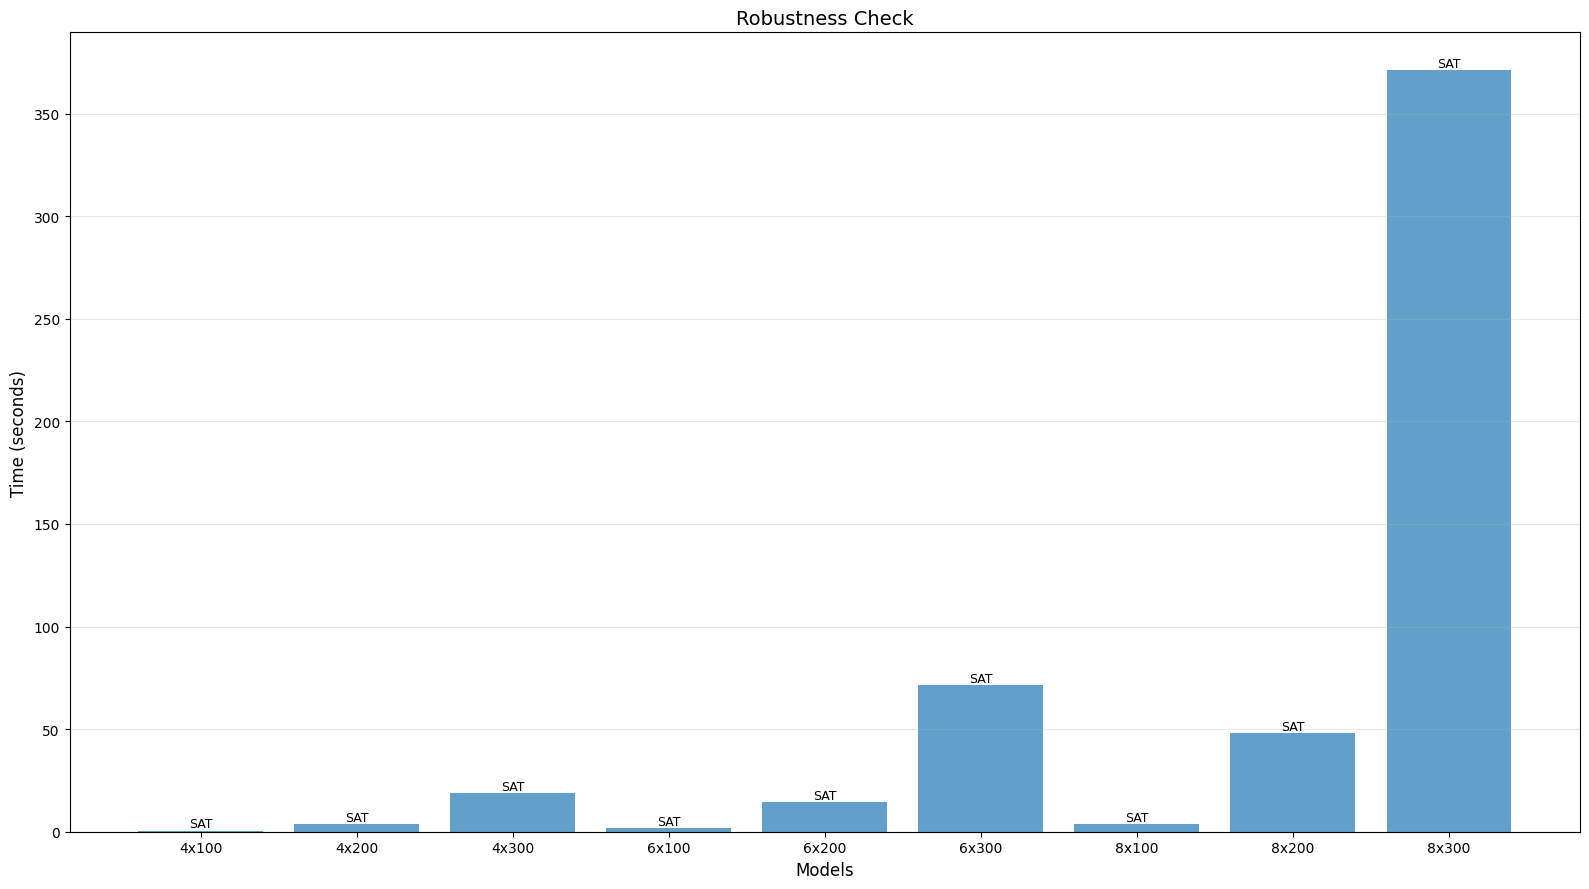

In [23]:
models = []
times = []
outcomes = []

for layers in range(4,9,2):

    for width in range(100, 301, 100):

        models.append(f"{layers}x{width}")

        model_path = f'../../models/{layers}_layers/model_{layers}x{width}.onnx'
        countereg, time_taken = epsilon_ball(model_path, 0.01)

        times.append(time_taken)

        print("Robustness Counter-example Found:", countereg)
        print("Time Taken:", time_taken)

        if countereg is not None:
            outcomes.append("SAT")
        else:
            outcomes.append("UNSAT")

    print()

plot_timing_results("Robustness", models, times, outcomes)

#### Conclusion

- Encoded and demonstrated the following properties:
    1. Counterfactual Fairness (Race)
    2. Counterfactual Fairness (Gender)
    3. Counterfactual Fairness (Marital Status)
    4. Counterfactual Fairness (Country of Origin)
    5. Robustness

- Note that among these, there are only two classes of properties (Robustness and Counterfactual Fairness). More could have been encoded, but iterating on Counterfactual Fairness seemed most appropriate given the problem statement.

- That being said, among the examples discussed [Chapter 3 of Introduction to Neural Network Verification](https://arxiv.org/pdf/2109.10317), **Monotonicity** would have been an interesting class of property to encode. An example has been demonstrated below.

### Monotonicity

#### Hours Worked

Let $HoursWorked(x)$ denote the hourse worked input parameter of $x$.

For any $x \in \mathcal{X}$ define $x' \geq x$ to be x with $HoursWorked(x)$ increased.
replaced (all other coordinates unchanged). The model is monotone at $x$ *iff*

$$ x \leq x' \implies \^{y}(x) \leq \^{y}(x')$$

**Verification target**: search for a violation—i.e., SAT of

$$ x \leq x' \implies \^{y}(x) > \^{y}(x')$$

We essentially expect that as the number of hours a person has worked increases, their net income will also increase. 
The above encoding would verify whether our model matches this expectation.

(Assumption: we live in a fair world and the economy isn't in shambles)